In [1]:
import os
import torch

print("=== GPU CHECK ===")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
    print("GPU Count:", torch.cuda.device_count())
else:
    print("CUDA NOT AVAILABLE")

DATASET_DIR = "/kaggle/input/datasets/vathsalupadhyay/modelnet40-cache-1024pts"

print("\n=== DATASET CHECK ===")
print("Dataset Path Exists:", os.path.exists(DATASET_DIR))
print("train.npz:", os.path.exists(os.path.join(DATASET_DIR, "train.npz")))
print("test.npz :", os.path.exists(os.path.join(DATASET_DIR, "test.npz")))

print("\n=== WORKING DIRECTORY CHECK ===")
print("/kaggle/working exists:", os.path.exists("/kaggle/working"))

print("\n=== OUTPUT WRITE TEST ===")
with open("/kaggle/working/test_write.txt", "w") as f:
    f.write("Kaggle output write successful")
print("Output write successful:", os.path.exists("/kaggle/working/test_write.txt"))

=== GPU CHECK ===
GPU: Tesla T4
CUDA Capability: (7, 5)
GPU Count: 2

=== DATASET CHECK ===
Dataset Path Exists: True
train.npz: True
test.npz : True

=== WORKING DIRECTORY CHECK ===
/kaggle/working exists: True

=== OUTPUT WRITE TEST ===
Output write successful: True


Device: Tesla T4
Train: 9843 (615 batches) | Test: 2468 (155 batches)
MSG params: 1,747,368
EMA enabled (decay=0.999)

epoch        lr    tr_loss     tr_acc    val_raw    val_ema     time
------------------------------------------------------------------------------
    1  1.00e-03     2.2083     0.5016     0.6216     0.0405   267.9s  *raw
    2  1.00e-03     1.6886     0.6694     0.7593     0.0405   266.6s  *raw
    3  9.99e-04     1.5314     0.7287     0.7934     0.0405   267.6s  *raw
    4  9.98e-04     1.4631     0.7502     0.8006     0.0405   267.1s  *raw
    5  9.96e-04     1.4027     0.7709     0.8152     0.0405   268.0s  *raw
    6  9.94e-04     1.3656     0.7810     0.8185     0.0405   267.3s  *raw
    7  9.91e-04     1.3367     0.7938     0.8160     0.0900   267.9s
    8  9.88e-04     1.2994     0.8051     0.8513     0.1240   267.1s  *raw
    9  9.84e-04     1.2902     0.8115     0.8404     0.4429   267.1s
   10  9.80e-04     1.2478     0.8238     0.8472     0.7613   267.4s
 

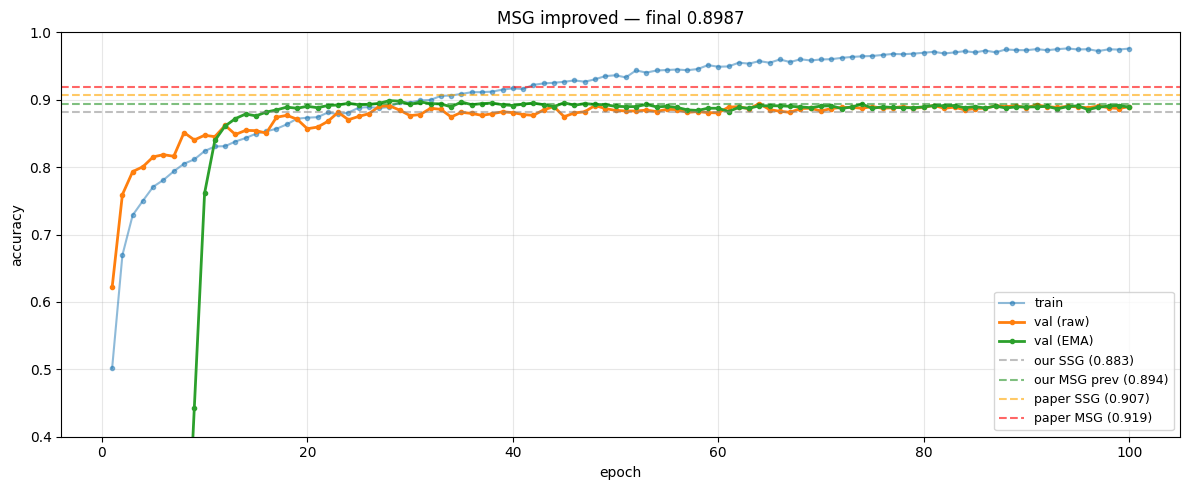


=== Per-class eval (EMA) ===
Acc: 0.8987  Macro F1: 0.8570  Coverage: 40/40
              precision    recall  f1-score   support

    airplane      1.000     1.000     1.000       100
     bathtub      0.959     0.940     0.949        50
         bed      0.970     0.960     0.965       100
       bench      0.609     0.700     0.651        20
   bookshelf      0.895     0.940     0.917       100
      bottle      0.934     0.990     0.961       100
        bowl      0.833     1.000     0.909        20
         car      0.990     0.980     0.985       100
       chair      0.933     0.970     0.951       100
        cone      1.000     0.950     0.974        20
         cup      0.567     0.850     0.680        20
     curtain      0.762     0.800     0.780        20
        desk      0.837     0.837     0.837        86
        door      0.810     0.850     0.829        20
     dresser      0.708     0.733     0.720        86
  flower_pot      0.167     0.050     0.077        20
   g

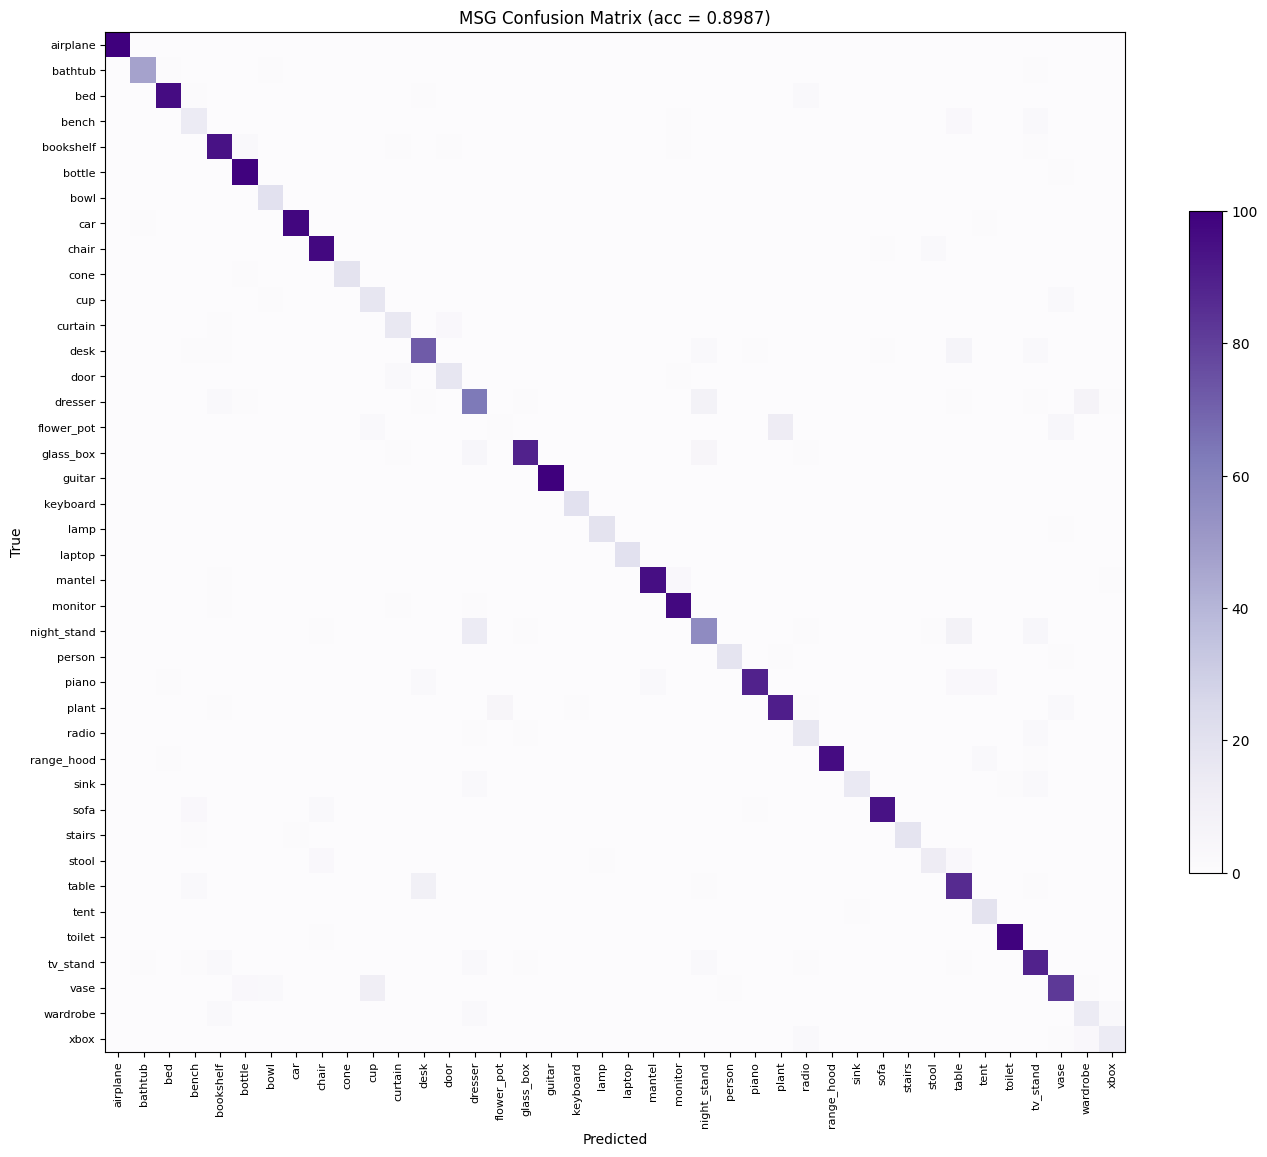


DONE. Outputs saved: pointnetpp_msg_best.pt, training_curves.png, msg_confusion_matrix.png


In [2]:
# ===============================================================
# PointNet++ MSG on ModelNet40 — Kaggle T4 (IMPROVED, target >0.90)
# Changes vs previous (0.8942):
#   1. EMA of weights (decay 0.999) — robust +0.3-0.7%
#   2. Random isotropic scaling [0.85, 1.25]
#   3. Random point dropout up to 12.5%
#   4. 100 epochs (was 80)
# ===============================================================

import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

SEED = 1234
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda", "No GPU!"
print(f"Device: {torch.cuda.get_device_name(0)}")

DATASET_DIR    = "/kaggle/input/datasets/vathsalupadhyay/modelnet40-cache-1024pts"
train_cache    = os.path.join(DATASET_DIR, "train.npz")
test_cache     = os.path.join(DATASET_DIR, "test.npz")
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
best_path   = os.path.join(CHECKPOINT_DIR, "pointnetpp_msg_best.pt")
latest_path = os.path.join(CHECKPOINT_DIR, "pointnetpp_msg_latest.pt")

CLASSES_M40 = ["airplane","bathtub","bed","bench","bookshelf","bottle","bowl","car","chair","cone",
               "cup","curtain","desk","door","dresser","flower_pot","glass_box","guitar","keyboard","lamp",
               "laptop","mantel","monitor","night_stand","person","piano","plant","radio","range_hood","sink",
               "sofa","stairs","stool","table","tent","toilet","tv_stand","vase","wardrobe","xbox"]

class AugmentedCachedModelNet40(Dataset):
    """Augmented: z-rotation + isotropic scaling + jitter + random point dropout."""
    def __init__(self, cache_path, augment=False):
        data = np.load(cache_path)
        self.points = data["points"]; self.labels = data["labels"]
        self.augment = augment
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        pts = self.points[idx].copy()
        if self.augment:
            # z-rotation
            theta = np.random.uniform(0, 2*np.pi); c, s = np.cos(theta), np.sin(theta)
            R = np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=np.float32)
            pts = pts @ R.T
            # isotropic scaling
            pts = pts * np.random.uniform(0.85, 1.25)
            # jitter
            jitter = np.clip(np.random.normal(0, 0.02, pts.shape), -0.05, 0.05).astype(np.float32)
            pts = pts + jitter
            # point dropout (replace with first point — standard PointNet++ trick)
            drop_ratio = np.random.uniform(0, 0.125)
            n_drop = int(drop_ratio * len(pts))
            if n_drop > 0:
                drop_idx = np.random.choice(len(pts), n_drop, replace=False)
                pts[drop_idx] = pts[0]
        return torch.from_numpy(pts), int(self.labels[idx])

BATCH_SIZE = 16
train_ds = AugmentedCachedModelNet40(train_cache, augment=True)
test_ds  = AugmentedCachedModelNet40(test_cache,  augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} ({len(train_loader)} batches) | Test: {len(test_ds)} ({len(test_loader)} batches)")

# --- FPS / Ball Query / SA (unchanged from before) ---
def farthest_point_sample(xyz, npoint):
    B, N, _ = xyz.shape; dev = xyz.device
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=dev)
    distance = torch.full((B, N), float("inf"), device=dev)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=dev)
    batch_idx = torch.arange(B, dtype=torch.long, device=dev)
    for i in range(npoint):
        centroids[:, i] = farthest
        cxyz = xyz[batch_idx, farthest, :].unsqueeze(1)
        dist = ((xyz - cxyz) ** 2).sum(dim=-1)
        distance = torch.minimum(distance, dist)
        farthest = distance.argmax(dim=-1)
    return centroids

def index_points(points, idx):
    B = points.shape[0]
    vs = list(idx.shape); vs[1:] = [1]*(len(vs)-1)
    rs = list(idx.shape); rs[0] = 1
    bi = torch.arange(B, dtype=torch.long, device=points.device).view(vs).repeat(rs)
    return points[bi, idx, :]

def ball_query(radius, nsample, xyz, new_xyz):
    B, N, _ = xyz.shape; _, S, _ = new_xyz.shape; dev = xyz.device
    gi = torch.arange(N, dtype=torch.long, device=dev).view(1, 1, N).repeat(B, S, 1)
    sd = ((new_xyz.unsqueeze(2) - xyz.unsqueeze(1)) ** 2).sum(dim=-1)
    gi[sd > radius**2] = N
    gi = gi.sort(dim=-1)[0][:, :, :nsample]
    gf = gi[:, :, 0:1].repeat(1, 1, nsample); gi[gi == N] = gf[gi == N]
    return gi

class SetAbstractionMSG(nn.Module):
    def __init__(self, npoint, radii, nsamples, in_channel, mlps):
        super().__init__()
        self.npoint, self.radii, self.nsamples = npoint, radii, nsamples
        self.conv_blocks, self.bn_blocks = nn.ModuleList(), nn.ModuleList()
        for mlp in mlps:
            convs, bns = nn.ModuleList(), nn.ModuleList(); last = in_channel + 3
            for c in mlp:
                convs.append(nn.Conv2d(last, c, 1)); bns.append(nn.BatchNorm2d(c)); last = c
            self.conv_blocks.append(convs); self.bn_blocks.append(bns)
    def forward(self, xyz, features=None):
        fps = farthest_point_sample(xyz, self.npoint)
        new_xyz = index_points(xyz, fps); outs = []
        for i, (r, k) in enumerate(zip(self.radii, self.nsamples)):
            nn_idx = ball_query(r, k, xyz, new_xyz)
            g_xyz = index_points(xyz, nn_idx) - new_xyz.unsqueeze(2)
            if features is not None:
                g = torch.cat([g_xyz, index_points(features, nn_idx)], dim=-1)
            else:
                g = g_xyz
            g = g.permute(0, 3, 1, 2).contiguous()
            for conv, bn in zip(self.conv_blocks[i], self.bn_blocks[i]):
                g = F.relu(bn(conv(g)))
            outs.append(g.max(dim=-1)[0])
        return new_xyz, torch.cat(outs, dim=1).permute(0, 2, 1).contiguous()

class GlobalSetAbstraction(nn.Module):
    def __init__(self, in_channel, mlp):
        super().__init__()
        self.convs, self.bns = nn.ModuleList(), nn.ModuleList(); last = in_channel
        for c in mlp:
            self.convs.append(nn.Conv1d(last, c, 1)); self.bns.append(nn.BatchNorm1d(c)); last = c
    def forward(self, xyz, features):
        x = torch.cat([xyz, features], dim=-1).permute(0, 2, 1)
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x)))
        return x.max(dim=-1)[0]

class PointNetPlusPlusMSG(nn.Module):
    def __init__(self, num_classes=40, dropout=0.5):
        super().__init__()
        self.sa1 = SetAbstractionMSG(512, [0.1,0.2,0.4], [16,32,128], 0,
                                     [[32,32,64],[64,64,128],[64,96,128]])
        self.sa2 = SetAbstractionMSG(128, [0.2,0.4,0.8], [32,64,128], 320,
                                     [[64,64,128],[128,128,256],[128,128,256]])
        self.sa_global = GlobalSetAbstraction(640+3, [256,512,1024])
        self.classifier = nn.Sequential(
            nn.Linear(1024,512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256,num_classes))
    def forward(self, xyz):
        l1_xyz, l1_f = self.sa1(xyz, None); l2_xyz, l2_f = self.sa2(l1_xyz, l1_f)
        return self.classifier(self.sa_global(l2_xyz, l2_f))


# --- EMA wrapper ---
class EMAModel:
    """Exponential Moving Average of model weights."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
            else:
                self.shadow[k] = v.detach().clone()


model = PointNetPlusPlusMSG(num_classes=40, dropout=0.5).to(device)
ema = EMAModel(model, decay=0.999)
inference_model = PointNetPlusPlusMSG(num_classes=40, dropout=0.5).to(device)
print(f"MSG params: {sum(p.numel() for p in model.parameters()):,}")
print("EMA enabled (decay=0.999)\n")

NUM_EPOCHS = 100
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)
scaler = torch.amp.GradScaler("cuda")
LABEL_SMOOTHING = 0.1

history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_acc_ema": [], "lr": []}
best_val_acc = 0.0; best_is_ema = False

print(f"{'epoch':>5}  {'lr':>8}  {'tr_loss':>9}  {'tr_acc':>9}  {'val_raw':>9}  {'val_ema':>9}  {'time':>7}")
print("-" * 78)
total_t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time(); cur_lr = optimizer.param_groups[0]["lr"]
    model.train(); loss_sum, correct, total = 0.0, 0, 0
    for pts, lbls in train_loader:
        pts = pts.to(device, non_blocking=True); lbls = lbls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda"):
            logits = model(pts)
            loss = F.cross_entropy(logits, lbls, label_smoothing=LABEL_SMOOTHING)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        ema.update(model)
        loss_sum += loss.item() * pts.size(0)
        correct += (logits.argmax(1) == lbls).sum().item(); total += pts.size(0)
    scheduler.step()
    tr_loss, tr_acc = loss_sum/total, correct/total

    # Validate raw weights
    model.eval(); vc, vt = 0, 0
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for pts, lbls in test_loader:
            pts = pts.to(device, non_blocking=True); lbls = lbls.to(device, non_blocking=True)
            vc += (model(pts).argmax(1) == lbls).sum().item(); vt += pts.size(0)
    val_acc = vc / vt

    # Validate EMA weights
    inference_model.load_state_dict(ema.shadow, strict=False)
    inference_model.eval(); vce, vte = 0, 0
    with torch.no_grad(), torch.amp.autocast("cuda"):
        for pts, lbls in test_loader:
            pts = pts.to(device, non_blocking=True); lbls = lbls.to(device, non_blocking=True)
            vce += (inference_model(pts).argmax(1) == lbls).sum().item(); vte += pts.size(0)
    val_acc_ema = vce / vte

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc); history["val_acc_ema"].append(val_acc_ema)
    history["lr"].append(cur_lr)

    torch.save({"epoch": epoch, "model": model.state_dict(),
                "ema_shadow": ema.shadow, "best_val_acc": best_val_acc,
                "history": history}, latest_path)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc; best_is_ema = False
        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "val_acc": val_acc, "is_ema": False}, best_path)
        flag = "  *raw"
    if val_acc_ema > best_val_acc:
        best_val_acc = val_acc_ema; best_is_ema = True
        torch.save({"epoch": epoch, "model": ema.shadow,
                    "val_acc": val_acc_ema, "is_ema": True}, best_path)
        flag = "  *EMA"

    print(f"{epoch:>5}  {cur_lr:>8.2e}  {tr_loss:>9.4f}  {tr_acc:>9.4f}  {val_acc:>9.4f}  {val_acc_ema:>9.4f}  {time.time()-t0:>6.1f}s{flag}")

print(f"\nTraining complete in {(time.time()-total_t0)/3600:.2f} hours\n")
print(f"=== FINAL RESULTS ===")
print(f"  Our SSG          : 0.8825")
print(f"  Our MSG (prev T4): 0.8942 (no EMA, 80 ep)")
print(f"  Our MSG (this)   : {best_val_acc:.4f}  (best was {'EMA' if best_is_ema else 'raw'})")
print(f"  Paper SSG        : 0.9070  gap: {best_val_acc - 0.907:+.4f}")
print(f"  Paper MSG        : 0.9190  gap: {best_val_acc - 0.919:+.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ep = range(1, len(history["train_acc"]) + 1)
ax.plot(ep, history["train_acc"], "-o", markersize=3, label="train", alpha=0.5)
ax.plot(ep, history["val_acc"],   "-o", markersize=3, label="val (raw)", linewidth=2)
ax.plot(ep, history["val_acc_ema"],"-o", markersize=3, label="val (EMA)", linewidth=2)
ax.axhline(0.8825, color="gray",   linestyle="--", alpha=0.5, label="our SSG (0.883)")
ax.axhline(0.8942, color="green",  linestyle="--", alpha=0.5, label="our MSG prev (0.894)")
ax.axhline(0.907,  color="orange", linestyle="--", alpha=0.6, label="paper SSG (0.907)")
ax.axhline(0.919,  color="red",    linestyle="--", alpha=0.6, label="paper MSG (0.919)")
ax.set(xlabel="epoch", ylabel="accuracy", title=f"MSG improved — final {best_val_acc:.4f}", ylim=(0.4, 1.0))
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("/kaggle/working/training_curves.png", dpi=100); plt.show()

# Per-class eval
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
ckpt = torch.load(best_path, map_location=device, weights_only=False)
inference_model.load_state_dict(ckpt["model"]); inference_model.eval()

all_preds, all_labels = [], []
with torch.no_grad(), torch.amp.autocast("cuda"):
    for pts, lbls in test_loader:
        pts = pts.to(device); lbls = lbls.to(device)
        all_preds.append(inference_model(pts).argmax(1).cpu().numpy())
        all_labels.append(lbls.cpu().numpy())
all_preds = np.concatenate(all_preds); all_labels = np.concatenate(all_labels)
acc = accuracy_score(all_labels, all_preds); macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\n=== Per-class eval ({'EMA' if ckpt.get('is_ema') else 'raw'}) ===")
print(f"Acc: {acc:.4f}  Macro F1: {macro_f1:.4f}  Coverage: {len(set(all_preds))}/40")
print(classification_report(all_labels, all_preds, target_names=CLASSES_M40, digits=3))

cm = confusion_matrix(all_labels, all_preds, labels=list(range(40)))
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks(range(40)); ax.set_yticks(range(40))
ax.set_xticklabels(CLASSES_M40, rotation=90, fontsize=8)
ax.set_yticklabels(CLASSES_M40, fontsize=8)
ax.set(xlabel="Predicted", ylabel="True", title=f"MSG Confusion Matrix (acc = {acc:.4f})")
plt.colorbar(im, ax=ax, shrink=0.6); plt.tight_layout()
plt.savefig("/kaggle/working/msg_confusion_matrix.png", dpi=100); plt.show()

print("\nDONE. Outputs saved: pointnetpp_msg_best.pt, training_curves.png, msg_confusion_matrix.png")